# Diffusion Models

This class of generative models aim to generate original data (images) by teaching a neural network to learn the diffusion process on a specific dataset, then using that neural to generate images inspired by that dataset.

The principles come directly from 19th- and 20th-century statistical physics applications, aimed at learning probability distributions from data.
For diffusion models we are training a NN to learn the noise distribution from data that we generate.

In this notebook, we study the application of diffusion models to the usual MNIST dataset.

### GPU setup

Training diffusion models can take a while. It is good to run this on a GPU if you have one.

In [25]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

## Prepare datasets

We continue to use this dataset only because it has a small input vector size 28x28, and because it is fast to load.

In [18]:
import torchvision
import torchvision.transforms.v2 as transforms_v2

toTensor = transforms_v2.Compose([transforms_v2.ToImage(), transforms_v2.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

### Variance Schedule

The schedule controls how much noise is added at each step in the forward process.

The free parameters are $s$ and $\beta_\mathrm{max}$.

In [19]:
import torch
def variance_schedule(T, s=0.008, max_beta=0.999):
    t = torch.linspace(0, T, T + 1)
    f = torch.cos((t / T + s) / (1 + s) * torch.pi / 2) ** 2
    alpha_bars = f / f[0]
    betas = (1 - (f[1:] / f[:-1])).clamp(max=max_beta)
    betas = torch.cat([torch.zeros(1), betas])  # for easier indexing
    alphas = 1 - betas
    return alphas, betas, alpha_bars

torch.manual_seed(42)  # extra code – for reproducibility
T = 4000
alphas, betas, alpha_bars = variance_schedule(T)

We can plot `alpha_bars` corresponding to $\bar \alpha$, used in the forward process shortcut. The vector contains all values in the time series.

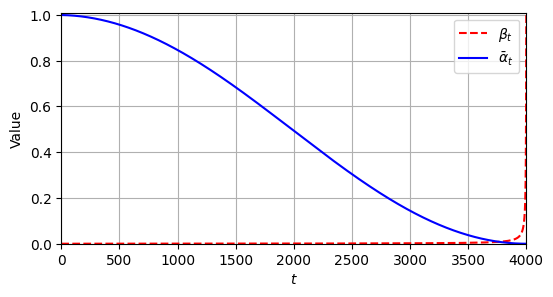

In [20]:
import matplotlib.pyplot as plt
# extra code – this cell generates Figure 18–21
plt.figure(figsize=(6, 3))
plt.plot(betas, "r--", label=r"$\beta_t$")
plt.plot(alpha_bars, "b", label=r"$\bar{\alpha}_t$")
plt.axis([0, T, 0, 1.01])
plt.grid(True)
plt.xlabel("$t$")
plt.ylabel(r"Value")
plt.legend()

plt.show()


### Forward diffusion

This is the implementation of the forward diffusion "shortcut", given $\bar\alpha$.

In [21]:
def forward_diffusion(x0, t):
    eps = torch.randn_like(x0)  # this unscaled noise will be the target
    xt = alpha_bars[t].sqrt() * x0 + (1 - alpha_bars[t]).sqrt() * eps
    return xt, eps

The `DiffusionSample` class holds the current information about the image and the corresponding time step.

In [22]:
from collections import namedtuple
class DiffusionSample(namedtuple("DiffusionSampleBase", ["xt", "t"])):
    def to(self, device):
        return DiffusionSample(self.xt.to(device), self.t.to(device))

Now we take the dataset, scale pixel values appropriately, and add noise for a random time step between 1 and $T$. This forms the training set for our DiffusionModel network. Remember that we are training to recover the noise added between any 2 adjacent time steps. The target value for the training is the unscaled noise `eps`.

In [23]:
from torch.utils.data import DataLoader

class DiffusionDataset:
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, i):
        x0, _ = self.dataset[i]
        x0 = (x0 * 2) - 1  # scale from –1 to +1
        t = torch.randint(1, T + 1, size=[1])
        xt, eps = forward_diffusion(x0, t)
        return DiffusionSample(xt, t), eps

    def __len__(self):
        return len(self.dataset)

train_set = DiffusionDataset(train_data)  # wrap Fashion MNIST
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = DiffusionDataset(valid_data)
valid_loader = DataLoader(valid_set, batch_size=32)

### Visualization

We can check a few training samples and the original images.
In the spirit of learning the noise, we recover the original images by subtracting the added noise, which we seek to learn.

You can see that the noise looks Gaussian, and the noisy images still bear some hints of the original images.

Original images


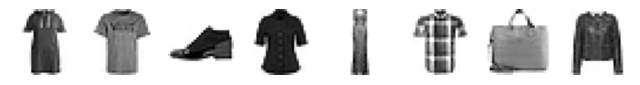

Time steps: [2027, 1463, 3720, 9, 611, 2202, 2118, 388]
Noisy images


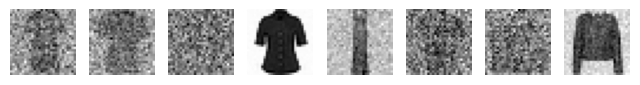

Noise to predict


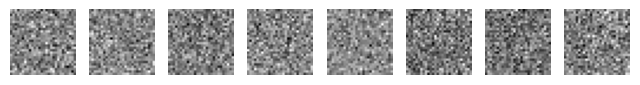

In [28]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap="binary")
    plt.axis("off")

def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plot_image(image)

def original_image(sample, noise):
    alpha_bars_t = torch.gather(alpha_bars, dim=0, index=sample.t.squeeze(1))
    alpha_bars_t = alpha_bars_t.view(-1, 1, 1, 1)
    x0 = (sample.xt - (1 - alpha_bars_t).sqrt() * noise) / alpha_bars_t.sqrt()
    return torch.clamp((x0 + 1) / 2, 0, 1)

torch.manual_seed(42)
sample, eps = next(iter(train_loader))  # get the first batch
x0 = original_image(sample, eps).to(device)

print("Original images")
plot_multiple_images(x0[:8])
plt.show()
print("Time steps:", sample.t[:8].view(-1).tolist())
print("Noisy images")
plot_multiple_images(sample.xt[:8])
plt.show()
print("Noise to predict")
plot_multiple_images(eps[:8])
plt.show()

# Building the model

We will use the U-Net architecture, but we have to encode the time steps using a sinusoidal encoding, just like for the attention-based transformeres.

In [30]:
import torch.nn as nn
embed_dim = 64

class TimeEncoding(nn.Module):
    def __init__(self, T, embed_dim):
        super().__init__()
        assert embed_dim % 2 == 0, "embed_dim must be even"
        p = torch.arange(T + 1).unsqueeze(1)
        angle = p / 10_000 ** (torch.arange(0, embed_dim, 2) / embed_dim)
        te = torch.empty(T + 1, embed_dim)
        te[:, 0::2] = torch.sin(angle)
        te[:, 1::2] = torch.cos(angle)
        self.register_buffer("time_encodings", te)

    def forward(self, t):
        return self.time_encodings[t]

### Implement the U-Net architecture

This very long block implements the U-Net architecture, based on the fully convolutional neural network (2-D in the case of our images).

You can pick out the "down path" and the "up path," and you can see the symmetry in the dimensionality of the layers.

Then the `forward` process adds all pooling layers and the `skip_link`s between the layers.

In [37]:
import torch.nn.functional as F

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size,
                                   padding=padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, X):
        return self.pointwise(self.depthwise(X))

class DiffusionModel(nn.Module):
    def __init__(self, T=T, embed_dim=64):
        super().__init__()
        self.time_encoding = TimeEncoding(T, embed_dim)

        # Init
        dim = 16
        self.pad = nn.ConstantPad2d((3, 3, 3, 3), 0)
        self.init_conv = nn.Conv2d(1, dim, kernel_size=3)
        self.init_bn = nn.BatchNorm2d(dim)
        self.time_adapter_init = nn.Linear(embed_dim, dim)

        # Down path
        self.down_blocks = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        self.time_adapters_down = nn.ModuleList()
        in_dim = dim
        for dim in (32, 64, 128):
            block = nn.Sequential(
                nn.ReLU(),
                SeparableConv2d(in_dim, dim, kernel_size=3, padding=1),
                nn.BatchNorm2d(dim),
                nn.ReLU(),
                SeparableConv2d(dim, dim, kernel_size=3, padding=1),
                nn.BatchNorm2d(dim)
            )
            skip_conv = nn.Conv2d(in_dim, dim, kernel_size=1, stride=2)
            self.down_blocks.append(block)
            self.skip_convs.append(skip_conv)
            self.time_adapters_down.append(nn.Linear(embed_dim, dim))
            in_dim = dim

        # Up path
        self.up_blocks = nn.ModuleList()
        self.skip_up_convs = nn.ModuleList()
        self.time_adapters_up = nn.ModuleList()
        for dim in (64, 32, 16):
            block = nn.Sequential(
                nn.ReLU(),
                nn.ConvTranspose2d(in_dim, dim, 3, padding=1),
                nn.BatchNorm2d(dim),
                nn.ReLU(),
                nn.ConvTranspose2d(dim, dim, 3, padding=1),
                nn.BatchNorm2d(dim)
            )
            skip_conv = nn.Conv2d(in_dim, dim, kernel_size=1)
            self.up_blocks.append(block)
            self.skip_up_convs.append(skip_conv)
            self.time_adapters_up.append(nn.Linear(embed_dim, dim))
            in_dim = dim * 3  # because of concatenation with cross skip

        self.final_conv = nn.Conv2d(in_dim, 1, 3, padding=1)

    def forward(self, sample):
        if not isinstance(sample, DiffusionSample):
            print(repr(sample))
        time_enc = self.time_encoding(sample.t.squeeze(1))  # [batch, embed_dim]
        z = self.pad(sample.xt)
        z = F.relu(self.init_bn(self.init_conv(z)))
        z = z + self.time_adapter_init(time_enc)[:, :, None, None]
        skip = z
        cross_skips = []

        # Downsampling path
        for block, skip_conv, time_adapter in zip(
                self.down_blocks, self.skip_convs, self.time_adapters_down):
            z = block(z)
            cross_skips.append(z)
            z = F.max_pool2d(z, 3, stride=2, padding=1)
            skip_link = skip_conv(skip)
            z = z + skip_link
            z = z + time_adapter(time_enc)[:, :, None, None]
            skip = z

        # Upsampling path
        for block, skip_up_conv, time_adapter in zip(
                self.up_blocks, self.skip_up_convs, self.time_adapters_up):
            z = block(z)
            z = F.interpolate(z, scale_factor=2, mode="nearest")
            skip_link = F.interpolate(skip, scale_factor=2, mode="nearest")
            skip_link = skip_up_conv(skip_link)
            z = z + skip_link
            z = z + time_adapter(time_enc)[:, :, None, None]
            cross_skip = cross_skips.pop()
            z = torch.cat([z, cross_skip], dim=1)
            skip = z

        out = self.final_conv(z)
        out = out[:, :, 2:-2, 2:-2]  # cropping
        return out.contiguous()

We use the same training methods as in the past.

In [38]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=2, factor=0.5, epoch_callback=None):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f"\rBatch {index + 1}/{len(train_loader)}", end="")
            print(f", loss={total_loss/(index+1):.4f}", end="")
            print(f", {train_metric=:.3f}", end="")
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"\rEpoch {epoch + 1}/{n_epochs},                      "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.3}, "
              f"valid metric: {history['valid_metrics'][-1]:.3}")
    return history


The only items to note in the training are
- metric is `rmse` because of the Gaussian nature of the ELBO simplification
- loss function is Huber
$$
L_{\delta}(r) =
\begin{cases}
\frac{1}{2} r^2 & \text{if } |r| \leq \delta \\
\delta \left(|r| - \frac{1}{2}\delta\right) & \text{if } |r| > \delta
\end{cases}
$$
which gives additional robustness against outliers (as opposed to L2 loss)

In [43]:
!pip install torchmetrics
import torchmetrics

torch.manual_seed(42)
diffusion_model = DiffusionModel().to(device)
huber = nn.HuberLoss()
optimizer = torch.optim.NAdam(diffusion_model.parameters(), lr=3e-3)
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train(diffusion_model, optimizer, huber, rmse, train_loader,
                valid_loader, n_epochs=20)

Epoch 1/20,                      train loss: 0.0867, train metric: 0.704, valid metric: 0.33
Epoch 2/20,                      train loss: 0.0480, train metric: 0.32, valid metric: 0.316
Epoch 3/20,                      train loss: 0.0452, train metric: 0.31, valid metric: 0.307
Epoch 4/20,                      train loss: 0.0702, train metric: 0.696, valid metric: 0.299
Epoch 5/20,                      train loss: 0.0419, train metric: 0.299, valid metric: 0.295
Epoch 6/20,                      train loss: 0.0414, train metric: 0.297, valid metric: 0.298
Epoch 7/20,                      train loss: 0.0413, train metric: 0.297, valid metric: 0.293
Epoch 8/20,                      train loss: 0.0406, train metric: 0.294, valid metric: 0.296
Epoch 9/20,                      train loss: 0.0403, train metric: 0.293, valid metric: 0.294
Epoch 10/20,                      train loss: 0.0403, train metric: 0.293, valid metric: 0.29
Epoch 11/20,                      train loss: 0.0396, train met

### Inference

After the model has been trained, we can use it to take Gaussian noise at time $T$, then predict the image at $T-1$, then $T-2$, etc.

At the end, we get something that looks like it is from the original training dataset.

In [44]:
def generate_ddpm(model, batch_size=32):
    model.eval()
    with torch.no_grad():
        xt = torch.randn([batch_size, 1, 28, 28], device=device)
        for t in range(T, 0, -1):
            print(f"\rt = {t}", end=" ")  # extra code — show progress
            alpha_t = alphas[t]
            beta_t = betas[t]
            alpha_bar_t = alpha_bars[t]
            noise = (torch.randn(xt.shape, device=device)
                     if t > 1 else torch.zeros(xt.shape, device=device))
            t_batch = torch.full((batch_size, 1), t, device=device)
            sample = DiffusionSample(xt, t_batch)
            eps_pred = model(sample)
            xt = (1 / alpha_t.sqrt()
                  * (xt - beta_t / (1 - alpha_bar_t).sqrt() * eps_pred)
                  + (1 - alpha_t).sqrt() * noise)
        return torch.clamp((xt + 1) / 2, 0, 1)

torch.manual_seed(42)  # extra code – ensures reproducibility
X_gen = generate_ddpm(diffusion_model)  # generated images

t = 1 

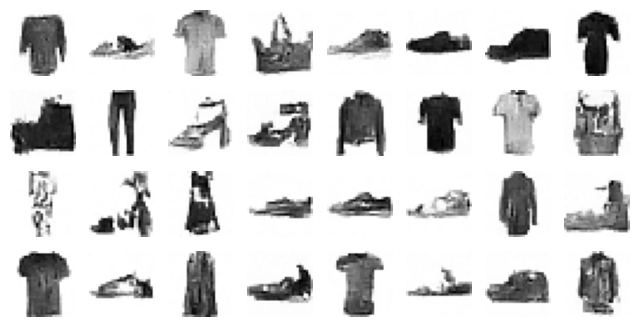

In [45]:
plot_multiple_images(X_gen, 8)
plt.show()

Thhe denoising diffusion implicit model (DDIM) can generate images in much fewer steps.
Instead of going from $t = 4000$ down to $0$ one step at a time, DDIM can go down any number of time steps at a time.

Test the time needed to take the system from $T=4000$ down to $T=0$.

In [46]:
def generate_ddim(model, batch_size=32, num_steps=50, eta=0.85):
    model.eval()
    with torch.no_grad():
        xt = torch.randn([batch_size, 1, 28, 28], device=device)
        times = torch.linspace(T - 1, 0, steps=num_steps + 1).long().tolist()
        for t, t_prev in zip(times[:-1], times[1:]):
            print(f"\rt = {t}", end=" ")
            t_batch = torch.full((batch_size, 1), t, device=device)
            sample = DiffusionSample(xt, t_batch)
            eps_pred = model(sample)
            x0 = ((xt - (1 - alpha_bars[t]).sqrt() * eps_pred)
                  / (alpha_bars[t].sqrt()))
            abar_t_prev = alpha_bars[t_prev]
            variance = eta * (1 - abar_t_prev) / (1 - alpha_bars[t]) * betas[t]
            sigma_t = variance.sqrt()
            pred_dir = (1 - abar_t_prev - sigma_t**2).sqrt() * eps_pred
            noise = torch.randn_like(xt)
            xt = abar_t_prev.sqrt() * x0 + pred_dir + sigma_t * noise

        return torch.clamp((xt + 1) / 2, 0, 1)  # from [–1, 1] range to [0, 1]

torch.manual_seed(42)  # extra code – ensures reproducibility
X_gen_ddim = generate_ddim(diffusion_model, num_steps=500)

t = 7 

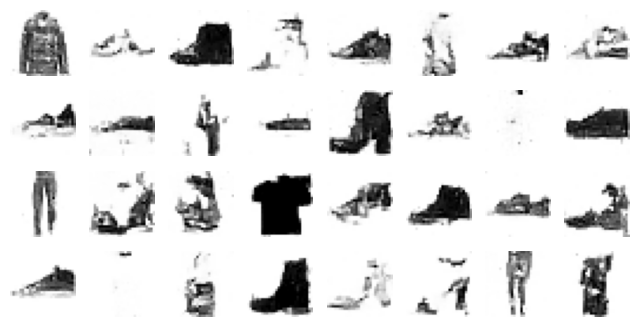

In [47]:
plot_multiple_images(X_gen_ddim, 8)
plt.show()